In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
train = np.load('/Users/jackbassham/thesis-rough/data/model_inputs/south/04222026_1201/train.npz')

test = np.load('/Users/jackbassham/thesis-rough/data/model_inputs/south/04222026_1201/test.npz')

In [18]:
def plot_x(input, time_index=0, channel_index=0, title=None):
    plt.pcolormesh(input['x'][time_index, channel_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

In [19]:
def plot_y(input, vector_index, time_index=0, title=None):
    plt.pcolormesh(input['y'][time_index, vector_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

In [20]:
features = [
    'ua_t0',
    'va_t0',
    'ci_t1',
    'mask'
]

targets = [
    'ui_t0',
    'vi_t0',
]

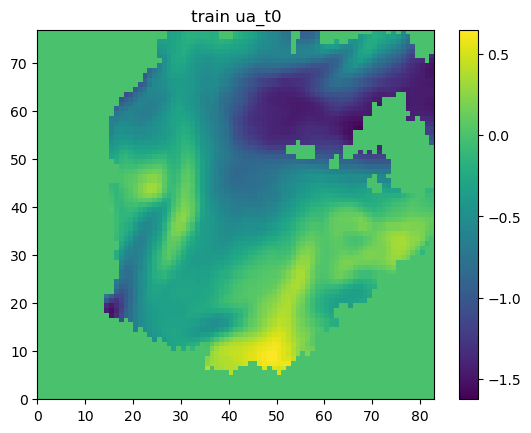

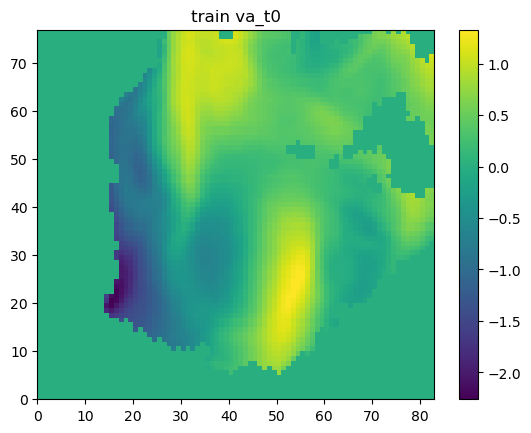

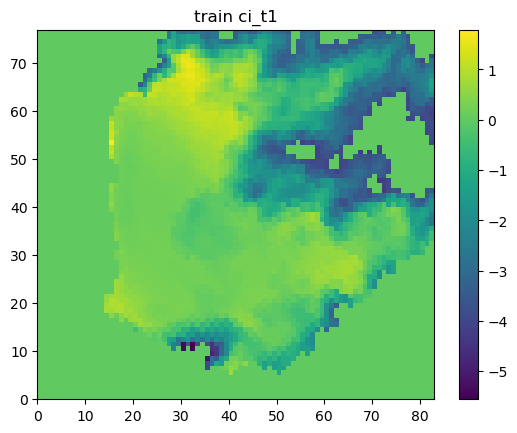

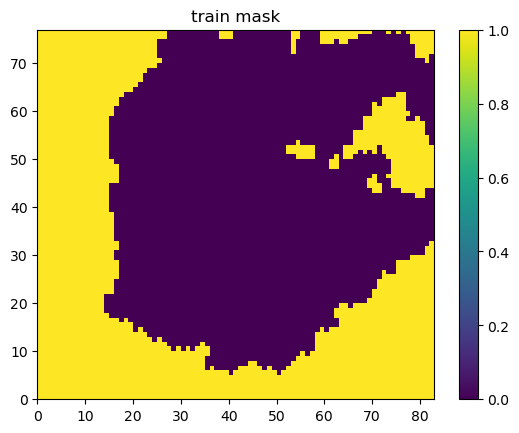

In [21]:
for i, feature in enumerate(features):
    plot_x(train, time_index=0, channel_index=i, title='train ' + feature)

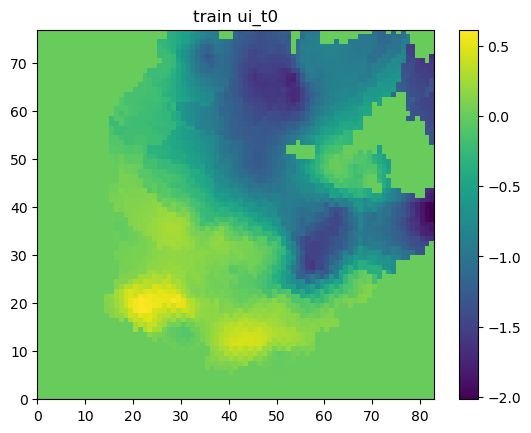

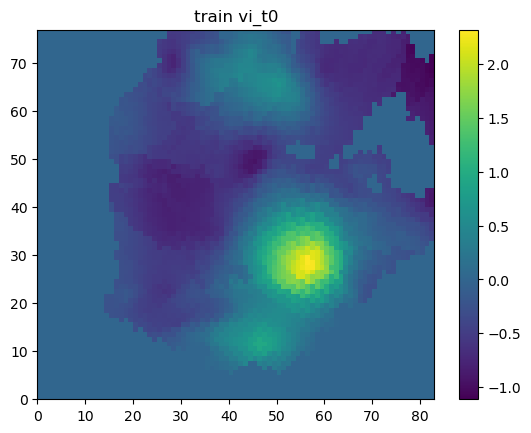

In [22]:
for i, target in enumerate(targets):
    plot_y(train, time_index=0, vector_index=i, title='train ' + target)

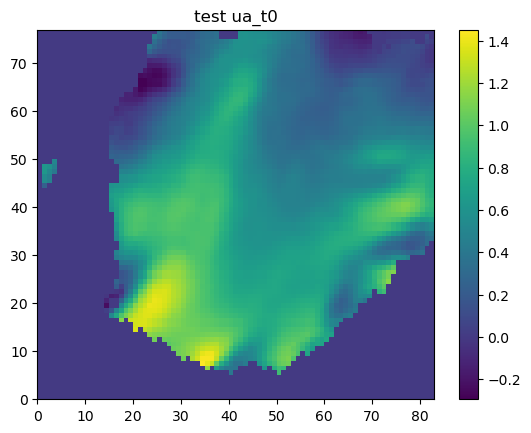

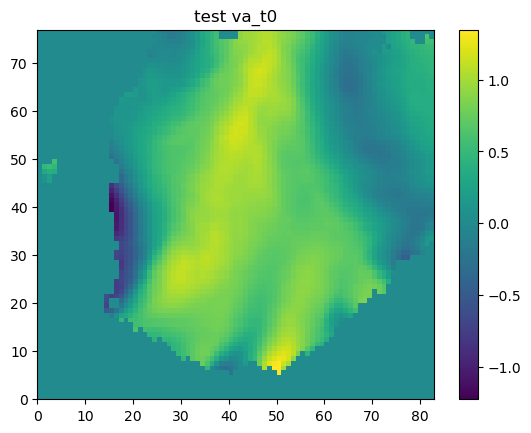

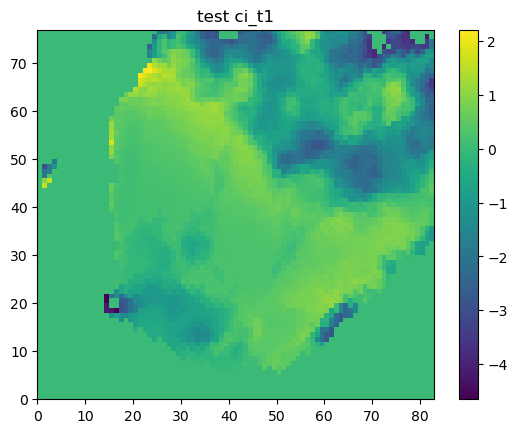

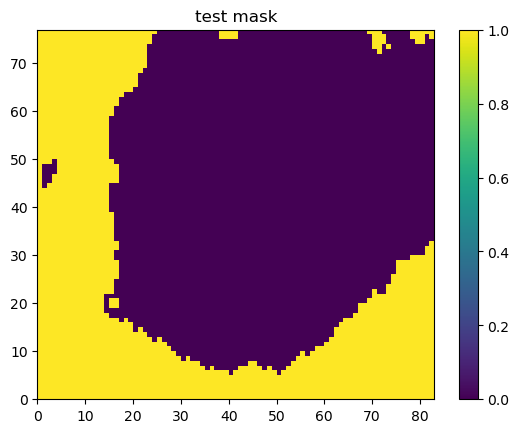

In [23]:
for i, feature in enumerate(features):
    plot_x(test, time_index=0, channel_index=i, title='test ' + feature)

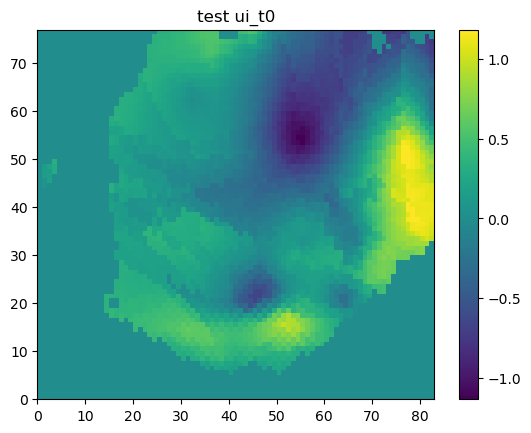

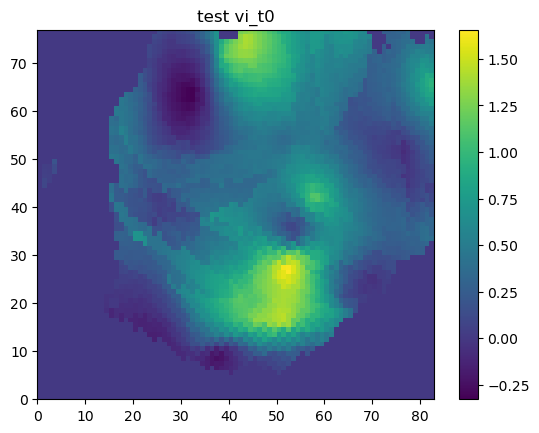

In [24]:
for i, target in enumerate(targets):
    plot_y(test, time_index=0, vector_index=i, title='test ' + target)

In [30]:
preds = np.load('/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/preds.npz')

In [31]:
print(preds.keys())

KeysView(NpzFile '/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/preds.npz' with keys: y_pred, y_true)


In [32]:
def plot(input, vector_index, time_index=0, key='None', title=None):
    if key is not None:
        plt.pcolormesh(input[key][time_index, vector_index, :, :])
    else:
        plt.pcolormesh(input[time_index, vector_index, :, :])
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.show()

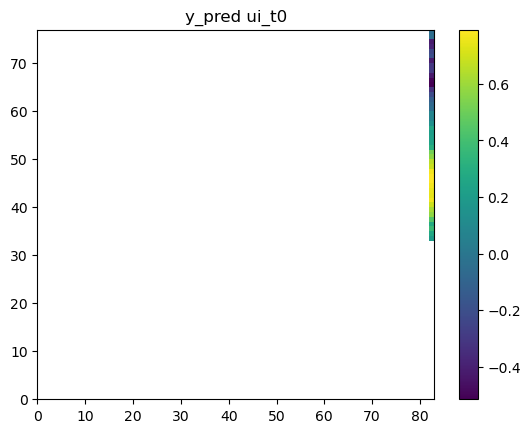

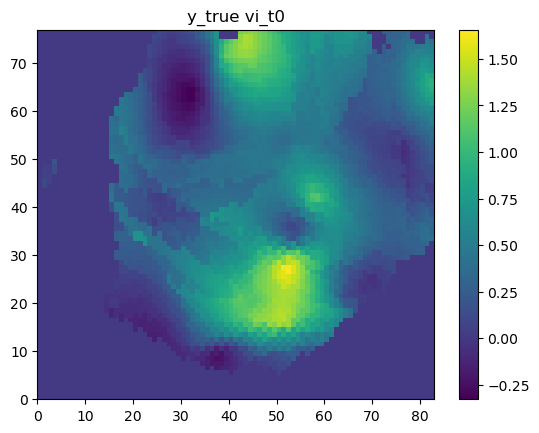

In [33]:
plot(preds, 0, time_index=0, key='y_pred', title='y_pred ui_t0')
plot(preds, 1, time_index=0, key='y_true', title='y_true vi_t0')

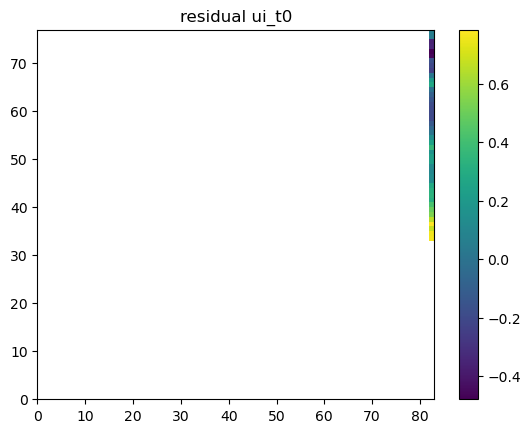

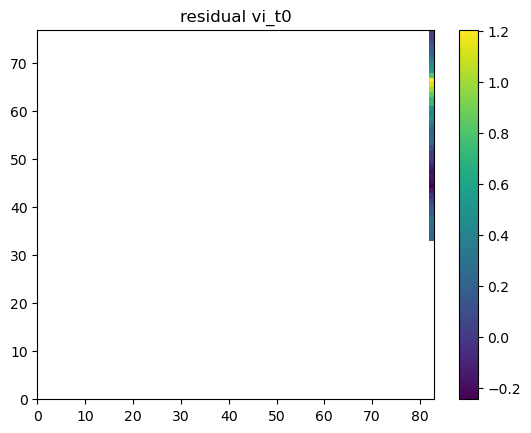

In [34]:
residual = preds['y_true'] - preds['y_pred']

plt.pcolormesh(residual[0, 0, :, :])
plt.colorbar()
plt.title('residual ui_t0')
plt.show()

plt.pcolormesh(residual[0, 1, :, :])
plt.colorbar()
plt.title('residual vi_t0')
plt.show()


In [35]:
coeff = np.load('/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/coeffients.npz')

In [36]:
print(coeff.keys())

KeysView(NpzFile '/Users/jackbassham/thesis-rough/data/model-output/lr_cf/south/04222026_1201/coeffients.npz' with keys: arr_0)


In [37]:
coeff['arr_0'].shape

(6, 77, 83)

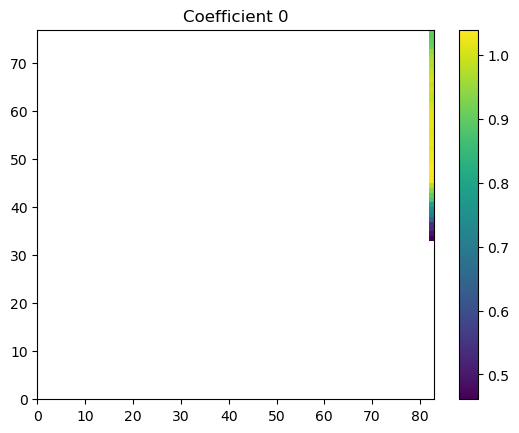

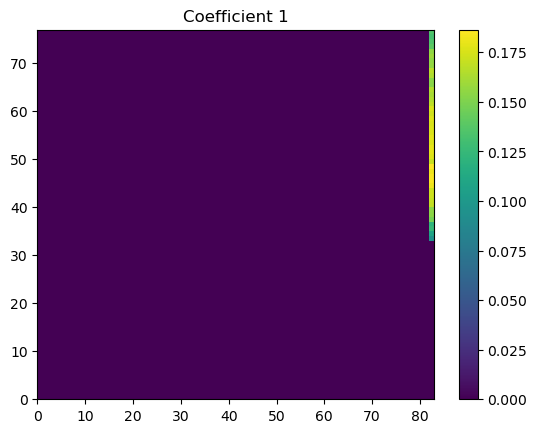

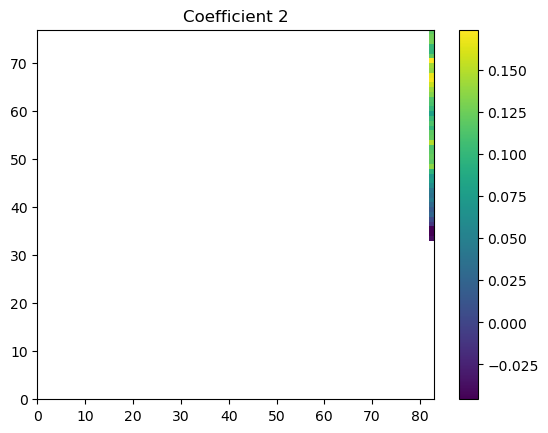

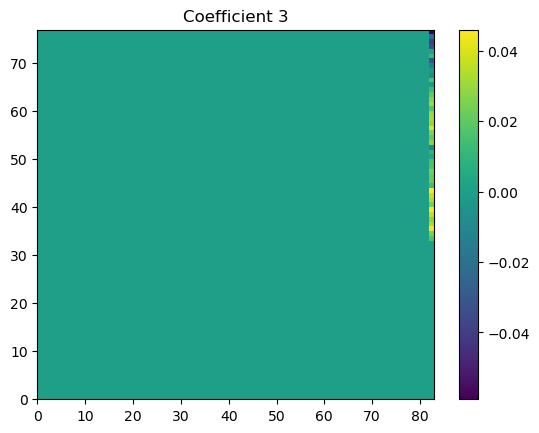

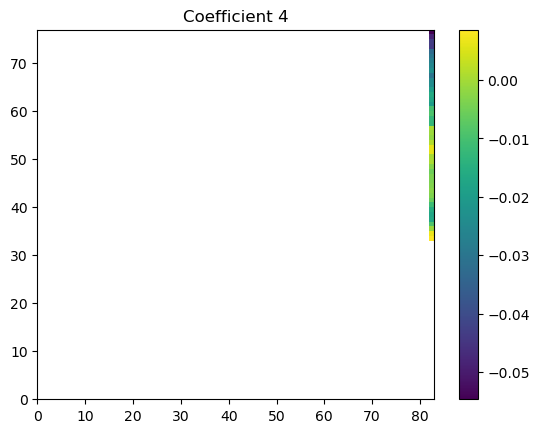

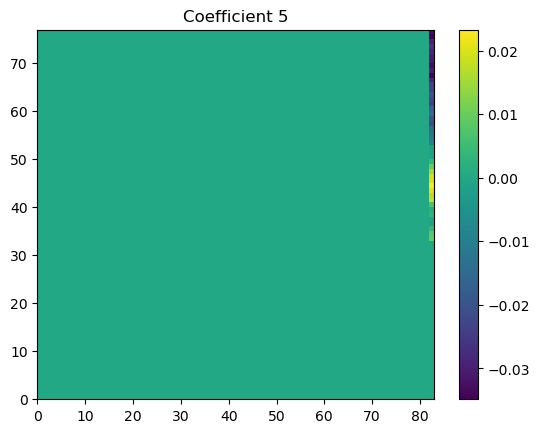

In [38]:
for i in range(coeff['arr_0'].shape[0]):
    plt.pcolormesh(coeff['arr_0'][i, :, :])
    plt.colorbar()
    plt.title(f'Coefficient {i}')
    plt.show()